# IEEE-CIS Fraud Detection – Data Preprocessing and Modeling
This notebook performs exploratory data analysis, preprocessing, model training, and explainability for fraud detection using the IEEE-CIS dataset.


# DATA COLLECTION

# 📥 Load Transaction Data
We begin by loading the transaction dataset which contains detailed information about each transaction, including fraud labels.

# 📥 Load Identity Data
The identity dataset includes user/device identity information linked to transactions.


In [1]:
import pandas as pd
df_transaction = pd.read_csv("C:\\Users\\amish\\Downloads\\ieee-fraud-detection\\train_transaction.csv")
df_identity = pd.read_csv("C:\\Users\\amish\\Downloads\\ieee-fraud-detection\\train_identity.csv")
display(df_transaction.head())
display(df_identity.head())

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


# 🔗 Merge Transaction and Identity Data
We merge the transaction and identity datasets using the `TransactionID` as the key.  
This combines transaction features with corresponding user identity features for a richer dataset.


In [2]:
df = df_transaction.merge(df_identity,on="TransactionID",how="left")
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


# Check Missing Values
We calculate the percentage of missing values for each column in the merged dataset.  
This helps identify which features have incomplete data and may need special handling.


In [3]:
# Check missing values percentage
missing_values = df.isnull().sum() / len(df) * 100

# Display columns with missing values
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Columns with Missing Values (%):")
print(missing_values)


Columns with Missing Values (%):
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
           ...    
V285      0.002032
V284      0.002032
V280      0.002032
V279      0.002032
V312      0.002032
Length: 414, dtype: float64


# 🛠️ Handle Missing Values
We now clean the dataset by handling missing values:
1. **Drop Columns**: Columns with more than 90% missing values are dropped.
2. **Fill Numerical Columns**: Remaining missing values in numerical features are filled with the median.
3. **Fill Categorical Columns**: Missing categorical values are replaced with `"Unknown"`.
Finally, we verify that no missing values are left.


In [4]:
# 1️⃣ Drop columns with more than 90% missing values  
threshold = 90  # Set threshold  
cols_to_drop = missing_values[missing_values > threshold].index.tolist()  
df.drop(columns=cols_to_drop, inplace=True)  

print(f"Dropped {len(cols_to_drop)} columns with >{threshold}% missing values.")

# 2️⃣ Fill numerical columns with median  
num_cols = df.select_dtypes(include=['number']).columns  
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))  

# 3️⃣ Fill categorical columns with "Unknown"  
cat_cols = df.select_dtypes(include=['object']).columns  
df[cat_cols] = df[cat_cols].fillna("Unknown")  

# ✅ Check if any missing values remain  
print("\nMissing Values After Cleaning:")
print(df.isnull().sum().sum())  # Should print 0 if all missing values are handled


Dropped 12 columns with >90% missing values.

Missing Values After Cleaning:
0


# 🗑️ Drop TransactionID
The `TransactionID` column is not needed for the machine learning model as it doesn't provide relevant information for prediction. We remove it from the dataset.


In [5]:
# Drop TransactionID (not needed for ML model)
df.drop(columns=["TransactionID"], inplace=True)

print(f"New dataset shape: {df.shape}")  # Should have 1 column less


New dataset shape: (590540, 421)


# 🔧 Create New Features Based on Transaction Amount and Time
We create additional features to enhance the model's performance:
- A **log-transformed** version of `TransactionAmt` to handle skewed data.
- Time-based features that capture the **hour** and **day** of the transaction.


In [6]:
# Create new features based on transaction amount
import numpy as np
df["TransactionAmt_Log"] = np.log1p(df["TransactionAmt"])  # Log-transform for skewed data

# Time-based features
df["Hour"] = df["TransactionDT"] // 3600 % 24  # Convert seconds to hours
df["Day"] = df["TransactionDT"] // (3600 * 24) % 7  # Convert to day of the week

print("New fraud-related features added!")


New fraud-related features added!


C:\Users\amish\AppData\Local\Temp\ipykernel_29328\2070161829.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["TransactionAmt_Log"] = np.log1p(df["TransactionAmt"])  # Log-transform for skewed data
C:\Users\amish\AppData\Local\Temp\ipykernel_29328\2070161829.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Hour"] = df["TransactionDT"] // 3600 % 24  # Convert seconds to hours
C:\Users\amish\AppData\Local\Temp\ipykernel_29328\2070161829.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

# 🔢 Encode Categorical Features Using Label Encoding
Categorical columns are encoded using **Label Encoding** to transform them into numerical values, as most machine learning algorithms require numerical data.


In [7]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Apply Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Categorical features encoded!")


Categorical features encoded!


## Load PaySim Dataset
We load the PaySim dataset, which contains transaction data from a mobile money transfer service. This dataset will be used to augment our model's training data.

## Display PaySim Dataset Preview
We display the first few rows of the dataset to get an overview of the structure and the information it contains.

## Check Column Names in PaySim
We inspect the column names in the PaySim dataset to understand its structure and identify the relevant features for our model.


In [8]:
# Load PaySim dataset
df_paysim = pd.read_csv("C:\\Users\\amish\\Downloads\\archive (1)\\PS_20174392719_1491204439457_log.csv")

# Display first few rows
print("PaySim Dataset Preview:")
display(df_paysim.head())

# Check column names
print("\nColumn Names in PaySim:")
print(df_paysim.columns)


PaySim Dataset Preview:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



Column Names in PaySim:
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


## Rename Columns to Match IEEE-CIS
We rename columns in the PaySim dataset to ensure consistency with the IEEE-CIS fraud detection dataset. This makes the data compatible for merging and feature extraction.

## Drop Unnecessary ID Columns
We drop columns such as `nameOrig` and `nameDest` that are not relevant for our fraud detection model.

## Add New Fraud-Related Features for Consistency
We create new features in the PaySim dataset to match the feature engineering from the IEEE-CIS dataset:
- A log-transformed `TransactionAmt_Log` to handle skewed data.
- `Hour` to represent the time of transaction.
- `Day` to capture the day of the transaction.

This ensures that the PaySim dataset is aligned with the feature structure of the IEEE-CIS dataset.


In [9]:
# Rename columns to match IEEE-CIS
df_paysim.rename(columns={
    "amount": "TransactionAmt",
    "isFraud": "isFraudLabel",  # Match IEEE-CIS fraud column
    "step": "TransactionDT"  # Convert step to time format
}, inplace=True)

# Drop unnecessary ID columns
df_paysim.drop(columns=["nameOrig", "nameDest"], inplace=True)

# Add new fraud-related features for consistency
df_paysim["TransactionAmt_Log"] = np.log1p(df_paysim["TransactionAmt"])  # Log transformation
df_paysim["Hour"] = df_paysim["TransactionDT"] % 24  # Convert step to hour
df_paysim["Day"] = df_paysim["TransactionDT"] // 24  # Convert step to day

print(f"Updated PaySim Dataset Shape: {df_paysim.shape}")
df_paysim.head()


Updated PaySim Dataset Shape: (6362620, 12)


,TransactionDT,type,TransactionAmt,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraudLabel,isFlaggedFraud,TransactionAmt_Log,Hour,Day
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,9.194276,1,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,7.531166,1,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,5.204007,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,5.204007,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,9.364703,1,0


## Rename PaySim Fraud Label to Match IEEE-CIS
We rename the `isFraudLabel` column in the PaySim dataset to `isFraud` to match the fraud label name in the IEEE-CIS dataset, ensuring consistency for model training.

## Align Column Orders
We align the column orders between the IEEE-CIS dataset (`df`) and the PaySim dataset (`df_paysim`) to ensure both datasets have the same structure. We select only the common columns shared by both datasets for the final merge.

## Merge Both Datasets
We combine the datasets from IEEE-CIS and PaySim into a single dataset (`df_combined`) using `concat()`. This creates a larger dataset with a mixture of transactions from both sources, ready for training the fraud detection model.


In [10]:
# Rename PaySim fraud label to match IEEE-CIS
df_paysim.rename(columns={"isFraudLabel": "isFraud"}, inplace=True)

# Align column orders
common_columns = list(set(df.columns) & set(df_paysim.columns))
df_paysim = df_paysim[common_columns]
df_ieee = df[common_columns]

# Merge both datasets
df_combined = pd.concat([df_ieee, df_paysim], ignore_index=True)

print(f"Final Merged Dataset Shape: {df_combined.shape}")
df_combined.head()

Final Merged Dataset Shape: (6953160, 6)


,isFraud,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour
0,0,4.241327,1,68.5,86400,0
1,0,3.401197,1,29.0,86401,0
2,0,4.094345,1,59.0,86469,0
3,0,3.931826,1,50.0,86499,0
4,0,3.931826,1,50.0,86506,0


## Check Fraud Class Distribution
We check the distribution of the fraud (`isFraud`) class in the combined dataset to understand the balance between fraud and non-fraud transactions.

## Calculate Fraud Percentage
We calculate the percentage of fraud transactions in the dataset, which helps in understanding the class imbalance and will inform us about the need for techniques like resampling during model training.


In [11]:
# Check fraud class distribution
fraud_count = df_combined["isFraud"].value_counts()
print("Fraud Distribution:\n", fraud_count)

# Calculate fraud percentage
fraud_pct = fraud_count[1] / fraud_count.sum() * 100
print(f"Fraud Transactions: {fraud_pct:.2f}% of total data")

Fraud Distribution:
 isFraud
0    6924284
1      28876
Name: count, dtype: int64
Fraud Transactions: 0.42% of total data


## Undersampling the Dataset to Handle Imbalance
We apply undersampling to reduce the number of non-fraud transactions in the dataset, balancing the fraud and non-fraud classes. The strategy keeps 10% of the non-fraud cases while preserving all the fraud cases.

### Feature & Label Separation
We separate the features (`X`) from the target label (`y`) and apply the undersampling technique to balance the dataset.

### Merged Balanced Dataset
We then merge the balanced features and labels back into a single dataframe and check the distribution of the `isFraud` column to confirm the balance.


In [12]:
from imblearn.under_sampling import RandomUnderSampler

# Define undersampling strategy (keep all fraud cases)
undersample = RandomUnderSampler(sampling_strategy=0.1, random_state=42)  # Keep 10% of non-fraud cases

# Separate features & labels
X = df_combined.drop(columns=["isFraud"])
y = df_combined["isFraud"]

# Apply undersampling
X_under, y_under = undersample.fit_resample(X, y)

# Merge back into a dataframe
df_balanced = X_under.copy()
df_balanced["isFraud"] = y_under

print(f"New Balanced Dataset Shape: {df_balanced.shape}")
print(df_balanced["isFraud"].value_counts())

New Balanced Dataset Shape: (317636, 6)
isFraud
0    288760
1     28876
Name: count, dtype: int64


## Display Columns in the Balanced Dataset
After applying the undersampling technique, we check the available columns in the balanced dataset (`df_balanced`) to ensure everything is correctly processed


In [13]:
print("Available Columns in df_balanced:")
print(df_balanced.columns)

Available Columns in df_balanced:
Index(['TransactionAmt_Log', 'Day', 'TransactionAmt', 'TransactionDT', 'Hour',
       'isFraud'],
      dtype='object')


## Feature Scaling
We apply Min-Max scaling to normalize the numerical columns `TransactionAmt` and `TransactionAmt_Log` in the balanced dataset. This ensures the features are within a specified range, typically [0, 1], which helps improve the model's performance


In [14]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler()

# Only scale available numerical columns
num_cols = ["TransactionAmt", "TransactionAmt_Log"]
df_balanced[num_cols] = scaler.fit_transform(df_balanced[num_cols])

print("Feature Scaling Completed!")
df_balanced.head()


Feature Scaling Completed!


,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour,isFraud
4994777,0.567562,13,0.000428,321,9,0
1593618,0.450180,1,0.000052,46,22,0
5959686,0.478824,15,0.000087,376,16,0
6235389,0.568112,16,0.000432,396,12,0
1571515,0.668959,1,0.002636,44,20,0


## Data Splitting
We split the balanced dataset into training and testing sets. The training set consists of 80% of the data, and the testing set consists of 20%. Stratified sampling ensures that the distribution of the target variable `isFraud` is maintained in both the training and testing sets


In [15]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target label (y)
X = df_balanced.drop(columns=["isFraud"])  # Features
y = df_balanced["isFraud"]  # Labels

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {X_train.shape}, Testing Set: {X_test.shape}")
print("Data Splitting Completed!")


Training Set: (254108, 5), Testing Set: (63528, 5)
Data Splitting Completed!


## Model Training and Evaluation
In this section, we initialize a Random Forest Classifier with 100 estimators and balanced class weights. The model is trained on the training data and evaluated on the test set. We compute several performance metrics including accuracy, precision, recall, F1 score, and print the classification report to evaluate the model's effectiveness in detecting fraud


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9567
Precision: 0.7705
Recall: 0.7463
F1 Score: 0.7582

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98     57753
           1       0.77      0.75      0.76      5775

    accuracy                           0.96     63528
   macro avg       0.87      0.86      0.87     63528
weighted avg       0.96      0.96      0.96     63528



## XGBoost Model Training and Evaluation
In this section, we initialize an XGBoost classifier with specific hyperparameters such as 300 estimators, a learning rate of 0.05, a maximum depth of 6, and a scale for positive class weights of 10. The model is trained on the training set and evaluated on the test set. Performance metrics such as accuracy, precision, recall, F1 score, and the classification report are computed to assess the model's performance in fraud detection.


In [17]:
from xgboost import XGBClassifier

# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, scale_pos_weight=10, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Accuracy: 0.8985
Precision: 0.4701
Recall: 0.9172
F1 Score: 0.6216

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.90      0.94     57753
           1       0.47      0.92      0.62      5775

    accuracy                           0.90     63528
   macro avg       0.73      0.91      0.78     63528
weighted avg       0.94      0.90      0.91     63528



## Advanced XGBoost Model Training and Evaluation

In this section, we fine-tune the XGBoost classifier by setting hyperparameters such as:

- `n_estimators=500`: Increasing the number of trees for better learning.
- `learning_rate=0.03`: Slower learning rate for improved accuracy.
- `max_depth=8`: Deeper trees capture more complex patterns.
- `scale_pos_weight=5`: Balancing the fraud and non-fraud class distribution.
- `gamma=0.1`: Helps reduce overfitting by controlling tree complexity.
- `colsample_bytree=0.8`: Uses 80% of features for each tree.
- `subsample=0.8`: Randomly samples 80% of the data for each tree.

The model is trained with the training data, and predictions are made on the test set. Various evaluation metrics such as accuracy, precision, recall, F1 score, and a full classification report are printed to assess the model's performance in fraud detection.
n.


In [18]:
xgb_model = XGBClassifier(
    n_estimators=500,          # More trees = better learning
    learning_rate=0.03,        # Slower learning for better accuracy
    max_depth=8,               # Deeper trees capture more patterns
    scale_pos_weight=5,        # Balances fraud & non-fraud
    gamma=0.1,                 # Reduces overfitting
    colsample_bytree=0.8,      # Uses 80% of features per tree
    subsample=0.8,             # Uses 80% of data per tree
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Accuracy: 0.9127
Precision: 0.5114
Recall: 0.8965
F1 Score: 0.6513

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95     57753
           1       0.51      0.90      0.65      5775

    accuracy                           0.91     63528
   macro avg       0.75      0.91      0.80     63528
weighted avg       0.95      0.91      0.92     63528



### GAN Model Training for Fraudulent Transaction Generation

- **Data Preprocessing**: Fraudulent transactions are extracted and normalized, then converted to PyTorch tensors.
- **Model Architecture**: A Generator creates synthetic fraudulent transactions, while a Discriminator distinguishes between real and fake transactions.
- **Training**: The Discriminator and Generator are trained in a standard GAN setup using Binary Cross-Entropy loss over 5000 epochs.
- **Hyperparameters**: Learning rate of 0.001, batch size of 32, and 5000 epochs.

This section generates synthetic fraudulent transactions using a GAN.


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load Fraud Transactions
fraud_data = df_balanced[df_balanced['isFraud'] == 1].drop(columns=['isFraud'])

# Normalize Features
scaler = MinMaxScaler()
fraud_data_scaled = scaler.fit_transform(fraud_data)

# Convert to PyTorch Tensors
real_fraud = torch.tensor(fraud_data_scaled, dtype=torch.float32)

# Define Generator
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Define Discriminator
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Model Parameters
input_dim = 10  # Random noise input size
output_dim = fraud_data.shape[1]  # Number of fraud transaction features

# Initialize GAN
generator = Generator(input_dim, output_dim)
discriminator = Discriminator(output_dim)

# Optimizers
lr = 0.001
g_optimizer = optim.Adam(generator.parameters(), lr=lr)
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

# Loss Function
criterion = nn.BCELoss()

# Training Parameters
epochs = 5000
batch_size = 32

# Training GAN
for epoch in range(epochs):
    # Generate Fake Fraud Transactions
    z = torch.randn(batch_size, input_dim)
    fake_fraud = generator(z)

    # Get Real Fraud Samples
    real_samples = real_fraud[torch.randint(0, real_fraud.shape[0], (batch_size,))]

    # Train Discriminator
    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    real_loss = criterion(discriminator(real_samples), real_labels)
    fake_loss = criterion(discriminator(fake_fraud.detach()), fake_labels)
    d_loss = real_loss + fake_loss

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Train Generator
    gen_loss = criterion(discriminator(fake_fraud), real_labels)

    g_optimizer.zero_grad()
    gen_loss.backward()
    g_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: D Loss: {d_loss.item():.4f}, G Loss: {gen_loss.item():.4f}")

print("GAN Training Completed!")


Epoch 0: D Loss: 1.3913, G Loss: 0.7471
Epoch 500: D Loss: 1.3798, G Loss: 0.7729
Epoch 1000: D Loss: 1.4784, G Loss: 0.7656
Epoch 1500: D Loss: 1.3376, G Loss: 0.6298
Epoch 2000: D Loss: 1.3541, G Loss: 0.6305
Epoch 2500: D Loss: 1.3485, G Loss: 0.6866
Epoch 3000: D Loss: 1.3243, G Loss: 0.7831
Epoch 3500: D Loss: 1.4086, G Loss: 0.7496
Epoch 4000: D Loss: 1.3102, G Loss: 0.7901
Epoch 4500: D Loss: 1.3773, G Loss: 0.7353
GAN Training Completed!


### Synthetic Fraud Transaction Generation

- **Goal**: Generate 1000 synthetic fraudulent transactions using the trained GAN model.
- **Process**: 
  - Random noise is passed through the Generator.
  - Synthetic fraud transactions are scaled back to their original range.
  - A DataFrame is created with fraud transactions labeled as `isFraud = 1`.

The result is a dataset of synthetic fraudulent transactions that can be used for further model training or testing.


In [21]:
# Generate 1000 Synthetic Fraud Transactions
z = torch.randn(1000, input_dim)
synthetic_fraud = generator(z).detach().numpy()

# Convert back to original scale
synthetic_fraud = scaler.inverse_transform(synthetic_fraud)

# Create DataFrame
synthetic_fraud_df = pd.DataFrame(synthetic_fraud, columns=fraud_data.columns)
synthetic_fraud_df['isFraud'] = 1  # Label as fraud

print("Generated Synthetic Fraud Transactions:")
print(synthetic_fraud_df.head())


Generated Synthetic Fraud Transactions:
   TransactionAmt_Log        Day  TransactionAmt  TransactionDT       Hour  \
0            0.877201  13.125342        0.027624     3030810.75  11.804908   
1            0.154269   0.938386       -0.002614    15702371.00  20.828135   
2            0.698466   6.030427        0.003407     3624396.00   2.735653   
3            0.227902   0.534354       -0.000787    11252360.00  20.297380   
4            0.251981   2.979176        0.005785    14005707.00  -0.059232   

   isFraud  
0        1  
1        1  
2        1  
3        1  
4        1  


### Merging Synthetic Fraud Data

- **Goal**: Add the synthetic fraud transactions to the balanced dataset.
- **Process**:
  - The synthetic fraud data is concatenated with the existing balanced dataset.
  - The dataset is shuffled to mix the real and synthetic data, ensuring better model performance during training.

The updated fraud distribution is then printed to verify the balance between fraud and non-fraudcases.


In [22]:
# Merge Synthetic Fraud Data with Balanced Dataset
df_balanced = pd.concat([df_balanced, synthetic_fraud_df], ignore_index=True)

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Print New Dataset Distribution
print("Updated Fraud Distribution:\n", df_balanced['isFraud'].value_counts())


Updated Fraud Distribution:
 isFraud
0    288760
1     29876
Name: count, dtype: int64


### Model Training with XGBoost

- **Goal**: Train an XGBoost model for fraud detection using the balanced dataset (including synthetic fraud data).
- **Steps**:
  - **Data Splitting**: The data is split into training (80%) and testing (20%) sets.
  - **XGBoost Model**: The model is trained with specific hyperparameters to handle the imbalance in the dataset, including `scale_pos_weight=10`.
  - **Evaluation**: The performance of the model is evaluated using accuracy, precision, recall, F1 score, and the classification report.

Results such as accuracy, precision, recall, and F1 score are printed, along with the detailed classification report to assess the model's performance.


In [23]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define features and target
X = df_balanced.drop(columns=['isFraud'])
y = df_balanced['isFraud']

# Split data into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, scale_pos_weight=10, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8991
Precision: 0.4801
Recall: 0.9195
F1 Score: 0.6308

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.90      0.94     57753
           1       0.48      0.92      0.63      5975

    accuracy                           0.90     63728
   macro avg       0.74      0.91      0.79     63728
weighted avg       0.94      0.90      0.91     63728



### WGAN (Wasserstein GAN) for Fraud Transaction Generation

- **Goal**: Implement a Wasserstein GAN (WGAN) to generate synthetic fraud transactions, focusing on improving training stability and output quality.

- **Key Components**:
  - **Generator**: A deep neural network that takes a latent vector and generates synthetic fraud transactions. It uses dense layers with ReLU activation and batch normalization.
  - **Critic (Discriminator in WGAN)**: The critic evaluates the quality of generated fraud transactions without a sigmoid activation, providing raw scores.
  - **Wasserstein Loss**: The loss function for WGAN, defined as the mean product of true and predicted values.
  - **Gradient Penalty**: To stabilize training, the gradient penalty term is added to the loss function to enforce the Lipschitz constraint.

These elements are essential for training a stable WGAN, and they will be utilized to generate synthetic fraud transactions in subsequent steps.


In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Define the Generator
def build_generator(latent_dim, output_dim):
    model = keras.Sequential([
        layers.Dense(128, activation="relu", input_dim=latent_dim),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),
        layers.Dense(output_dim, activation="tanh")  # Output fraud transactions
    ])
    return model

# Define the Discriminator (Critic in WGAN)
def build_critic(input_dim):
    model = keras.Sequential([
        layers.Dense(512, activation="relu", input_dim=input_dim),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(1)  # No activation, raw score output for WGAN
    ])
    return model

# Wasserstein Loss
class WassersteinLoss(keras.losses.Loss):
    def call(self, y_true, y_pred):
        return tf.reduce_mean(y_true * y_pred)

# Gradient Penalty (for WGAN-GP stability)
def gradient_penalty(critic, real_data, fake_data):
    batch_size = real_data.shape[0]
    alpha = tf.random.uniform([batch_size, 1], 0.0, 1.0)
    interpolated = alpha * real_data + (1 - alpha) * fake_data
    
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        pred = critic(interpolated)
    
    gradients = tape.gradient(pred, interpolated)
    norm = tf.sqrt(tf.reduce_sum(tf.square(gradients), axis=1))
    gp = tf.reduce_mean((norm - 1.0) ** 2)
    return gp


### GAN Model for Synthetic Fraud Transaction Generation

- **Goal**: Build a Generative Adversarial Network (GAN) for generating synthetic fraud transactions.
  
- **Models**:
  - **Generator**:
    - Takes random noise as input and generates synthetic fraud transactions with a structure matching the real data.
    - Uses ReLU activations and a Tanh activation function in the final layer for normalized output.
  - **Discriminator**:
    - Takes fraud transaction data (real or generated) and classifies it as either real or fake.
    - Uses Sigmoid activation in the final layer for binary classification.

- **Training**:
  - **Loss Function**: Binary Cross-Entropy Loss (BCELoss) is used for both the generator and the discriminator.
  - **Optimizers**: Adam optimizer is used for both models with a learning rate of 0.0002, suitable for GANs.

This setup will be used to train the models and generate synthetic fraud transactions during further steps.


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim

# Generator Model
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Define input dimensions
input_dim = 10  # Random noise dimension
output_dim = 5  # Number of features in fraud transactions

# Instantiate models
generator = Generator(input_dim, output_dim)
discriminator = Discriminator(output_dim)

# Loss function and optimizers
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)

print("GAN Model Initialized!")


GAN Model Initialized!


### Check Existing DataFrames in the Environment

The following command lists all DataFrame objects present in the current environment:

In [29]:
%whos DataFrame


Variable             Type         Data/Info
-------------------------------------------
X                    DataFrame            TransactionAmt_Lo<...>[318636 rows x 5 columns]
X_test               DataFrame            TransactionAmt_Lo<...>n[63728 rows x 5 columns]
X_train              DataFrame            TransactionAmt_Lo<...>[254908 rows x 5 columns]
X_under              DataFrame             TransactionAmt_L<...>[317636 rows x 5 columns]
df                   DataFrame            isFraud  Transact<...>90540 rows x 424 columns]
df_balanced          DataFrame            TransactionAmt_Lo<...>[318636 rows x 6 columns]
df_combined          DataFrame             isFraud  Transac<...>6953160 rows x 6 columns]
df_identity          DataFrame            TransactionID  id<...>144233 rows x 41 columns]
df_ieee              DataFrame            isFraud  Transact<...>[590540 rows x 6 columns]
df_paysim            DataFrame             isFraud  Transac<...>6362620 rows x 6 columns]
df_transacti

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

# Train on the training dataset
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Performance:
Accuracy: 0.9577108963093146
Precision: 0.7854159415245389
Recall: 0.7553138075313808
F1 Score: 0.7700708130705571

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98     57753
           1       0.79      0.76      0.77      5975

    accuracy                           0.96     63728
   macro avg       0.88      0.87      0.87     63728
weighted avg       0.96      0.96      0.96     63728



In [31]:
from xgboost import XGBClassifier

# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, scale_pos_weight=10, random_state=42)

# Train on the training dataset
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate performance
print("XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Performance:
Accuracy: 0.8991024353502385
Precision: 0.48011884995193566
Recall: 0.9194979079497908
F1 Score: 0.6308416580548858

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.90      0.94     57753
           1       0.48      0.92      0.63      5975

    accuracy                           0.90     63728
   macro avg       0.74      0.91      0.79     63728
weighted avg       0.94      0.90      0.91     63728



In [32]:
import pandas as pd
import numpy as np

# Function to apply rule-based fraud detection
def apply_fraud_rules(df):
    df = df.copy()
    
    # Rule 1: High Transaction Amount (95th percentile as threshold)
    high_amt_threshold = df['TransactionAmt'].quantile(0.95)
    df['rule_high_amt'] = (df['TransactionAmt'] > high_amt_threshold).astype(int)
    
    # Rule 2: Rapid Transactions - More than 3 transactions in 5 minutes
    df['synthetic_user_id'] = df['card1'].astype(str) + "_" + df['card2'].astype(str)
    df['TransactionDT_diff'] = df.groupby('synthetic_user_id')['TransactionDT'].diff().fillna(np.inf)
    df['rule_rapid_txns'] = (df['TransactionDT_diff'] < 300).astype(int)  # 300 sec = 5 min
    
    # Rule 3: New User making large transaction (new user = first transaction)
    df['rule_new_user_large_txn'] = ((df['TransactionDT_diff'] == np.inf) & (df['TransactionAmt'] > high_amt_threshold)).astype(int)
    
    # Rule 4: High-Risk Hours (0 AM - 4 AM)
    df['rule_high_risk_hours'] = df['Hour'].apply(lambda x: 1 if x in [0, 1, 2, 3, 4] else 0)
    
    # Combine all rules (if any rule flags fraud, set rule-based fraud label)
    df['rule_based_fraud'] = df[['rule_high_amt', 'rule_rapid_txns', 'rule_new_user_large_txn', 'rule_high_risk_hours']].max(axis=1)
    
    return df

# Apply rules to dataset
df = apply_fraud_rules(df)

# Check rule-based fraud distribution
print("Rule-Based Fraud Counts:")
print(df['rule_based_fraud'].value_counts())


Rule-Based Fraud Counts:
rule_based_fraud
0    377918
1    212622
Name: count, dtype: int64


In [33]:
print(df.columns)


Index(['isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1',
       'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'TransactionAmt_Log', 'Hour', 'Day', 'rule_high_amt',
       'synthetic_user_id', 'TransactionDT_diff', 'rule_rapid_txns',
       'rule_new_user_large_txn', 'rule_high_risk_hours', 'rule_based_fraud'],
      dtype='object', length=431)


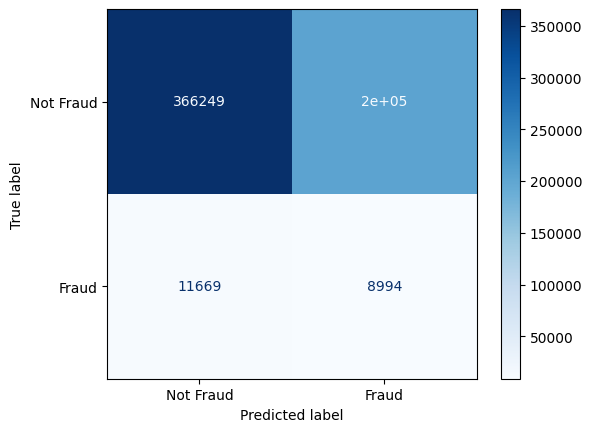

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(df["isFraud"], df["rule_based_fraud"])

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap="Blues")


Total False Negatives: 481
count    481.000000
mean       0.007447
std        0.020151
min        0.000000
25%        0.001002
50%        0.002844
75%        0.006122
max        0.161986
Name: TransactionAmt, dtype: float64

True Positives Transaction Amount Distribution:
count    5.494000e+03
mean     6.389970e-03
std      2.303529e-02
min     -4.792388e-03
25%      7.032133e-07
50%      1.874525e-06
75%      9.790105e-06
max      1.619859e-01
Name: TransactionAmt, dtype: float64


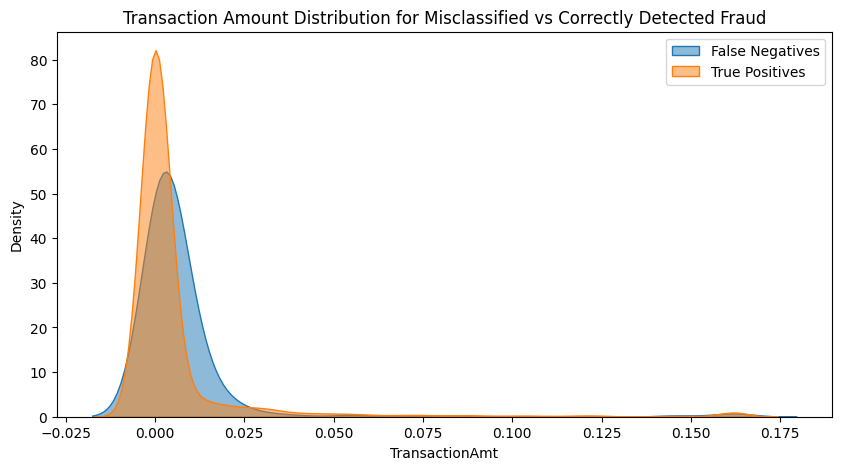

In [35]:
# Identify false negatives (missed frauds)
false_negatives = X_test[(y_test == 1) & (y_pred == 0)]
print(f"Total False Negatives: {len(false_negatives)}")

# Check distribution of transaction amounts
print(false_negatives["TransactionAmt"].describe())

# Compare with correctly classified fraud cases
true_positives = X_test[(y_test == 1) & (y_pred == 1)]
print("\nTrue Positives Transaction Amount Distribution:")
print(true_positives["TransactionAmt"].describe())

# Optional: Visualize distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.kdeplot(false_negatives["TransactionAmt"], label="False Negatives", fill=True, alpha=0.5)
sns.kdeplot(true_positives["TransactionAmt"], label="True Positives", fill=True, alpha=0.5)
plt.legend()
plt.title("Transaction Amount Distribution for Misclassified vs Correctly Detected Fraud")
plt.show()


In [36]:
# Check negative transaction amounts
negative_transactions = X_test[X_test["TransactionAmt"] < 0]
print(f"Total Negative Transactions: {len(negative_transactions)}")
print(negative_transactions[["TransactionAmt"]].head())


Total Negative Transactions: 121
        TransactionAmt
228461       -0.002546
58615        -0.002669
66196        -0.004101
130376       -0.002550
97255        -0.002448


In [37]:
# Check how many negative transactions are labeled as fraud
negative_fraud_cases = y_test[X_test["TransactionAmt"] < 0]
print(negative_fraud_cases.value_counts())


isFraud
1    121
Name: count, dtype: int64


In [38]:
# Find the original unscaled transaction amounts
original_negatives = df_ieee[df_ieee["TransactionAmt"] < 0]
print(original_negatives[["TransactionAmt", "isFraud"]])


Empty DataFrame
Columns: [TransactionAmt, isFraud]
Index: []


In [39]:
# Initialize the same MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the original TransactionAmt before scaling
scaler.fit(df_balanced[["TransactionAmt", "TransactionAmt_Log"]])

# Reverse the transformation
df_balanced[["TransactionAmt", "TransactionAmt_Log"]] = scaler.inverse_transform(df_balanced[["TransactionAmt", "TransactionAmt_Log"]])

print("Inverse Scaling Completed!")
df_balanced.head()


Inverse Scaling Completed!


,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour,isFraud
0,0.257277,2.0,-0.007799,10481694.0,7.0,0
1,0.701934,0.0,-0.003000,16.0,16.0,0
2,0.556525,5.0,-0.007447,130.0,10.0,0
3,0.463893,15.0,-0.007734,360.0,0.0,0
4,0.647071,8.0,-0.006007,204.0,12.0,0


In [40]:
print(df_balanced[df_balanced["TransactionAmt"] < 0])


        TransactionAmt_Log   Day  TransactionAmt  TransactionDT  Hour  isFraud
0                 0.257277   2.0       -0.007799     10481694.0   7.0        0
1                 0.701934   0.0       -0.003000           16.0  16.0        0
2                 0.556525   5.0       -0.007447          130.0  10.0        0
3                 0.463893  15.0       -0.007734          360.0   0.0        0
4                 0.647071   8.0       -0.006007          204.0  12.0        0
...                    ...   ...             ...            ...   ...      ...
318630            0.597801  10.0       -0.007060          251.0  11.0        0
318631            0.702531  12.0       -0.002949          308.0  20.0        0
318633            0.219186   3.0       -0.007800      8738916.0   3.0        0
318634            0.630779  11.0       -0.006461          283.0  19.0        0
318635            0.710267  14.0       -0.002226          354.0  18.0        0

[299274 rows x 6 columns]


In [41]:
print("Before Scaling:")
print("Min:", df_balanced["TransactionAmt"].min())
print("Max:", df_balanced["TransactionAmt"].max())


Before Scaling:
Min: -0.015662650108424766
Max: 1.0


In [42]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Select numerical columns
num_cols = ["TransactionAmt", "TransactionAmt_Log"]

# Fit and transform
df_balanced[num_cols] = scaler.fit_transform(df_balanced[num_cols])

print("Feature Scaling Completed!")


Feature Scaling Completed!


In [43]:
print("After Scaling:")
print("Min:", df_balanced["TransactionAmt"].min())
print("Max:", df_balanced["TransactionAmt"].max())


After Scaling:
Min: 0.0
Max: 1.0


In [44]:
df_balanced[num_cols] = scaler.inverse_transform(df_balanced[num_cols])

print("After Inverse Scaling:")
print("Min:", df_balanced["TransactionAmt"].min())
print("Max:", df_balanced["TransactionAmt"].max())


After Inverse Scaling:
Min: -0.015662650108424766
Max: 1.0


In [45]:
# Ensure TransactionAmt is non-negative
df_balanced["TransactionAmt"] = df_balanced["TransactionAmt"].clip(lower=0)

print("Fixed Negative Values:")
print("Min:", df_balanced["TransactionAmt"].min())
print("Max:", df_balanced["TransactionAmt"].max())


Fixed Negative Values:
Min: 0.0
Max: 1.0


In [46]:
df_balanced.head()


,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour,isFraud
0,0.257277,2.0,0.0,10481694.0,7.0,0
1,0.701934,0.0,0.0,16.0,16.0,0
2,0.556525,5.0,0.0,130.0,10.0,0
3,0.463893,15.0,0.0,360.0,0.0,0
4,0.647071,8.0,0.0,204.0,12.0,0


In [47]:
# Ensure no zero values in TransactionAmt
df_balanced["TransactionAmt"] = df_balanced["TransactionAmt"].replace(0, df_balanced["TransactionAmt"].mean())

print("Fixed Zero Values:")
print(df_balanced["TransactionAmt"].describe())


Fixed Zero Values:
count    3.186360e+05
mean     2.221111e-03
std      1.094085e-02
min      5.443883e-07
25%      1.145354e-03
50%      1.145354e-03
75%      1.145354e-03
max      1.000000e+00
Name: TransactionAmt, dtype: float64


In [48]:
df_balanced.head()


,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour,isFraud
0,0.257277,2.0,0.001145,10481694.0,7.0,0
1,0.701934,0.0,0.001145,16.0,16.0,0
2,0.556525,5.0,0.001145,130.0,10.0,0
3,0.463893,15.0,0.001145,360.0,0.0,0
4,0.647071,8.0,0.001145,204.0,12.0,0


In [49]:
# Compute median TransactionAmt per user
df_balanced["user_median_amt"] = df_balanced.groupby("Day")["TransactionAmt"].transform("median")

# Create ratio feature
df_balanced["amt_ratio"] = df_balanced["TransactionAmt"] / (df_balanced["user_median_amt"] + 1e-6)

# Drop temporary column
df_balanced.drop(columns=["user_median_amt"], inplace=True)

print("✅ Transaction Amount Ratio Feature Added!")
df_balanced.head()


✅ Transaction Amount Ratio Feature Added!


,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour,isFraud,amt_ratio
0,0.257277,2.0,0.001145,10481694.0,7.0,0,0.999128
1,0.701934,0.0,0.001145,16.0,16.0,0,0.999128
2,0.556525,5.0,0.001145,130.0,10.0,0,0.999128
3,0.463893,15.0,0.001145,360.0,0.0,0,0.999128
4,0.647071,8.0,0.001145,204.0,12.0,0,0.999128


In [50]:
# Compute time difference per user
df_balanced["prev_txn_time"] = df_balanced.groupby("Day")["TransactionDT"].shift(1)

# Calculate time difference
df_balanced["txn_time_diff"] = df_balanced["TransactionDT"] - df_balanced["prev_txn_time"]

# Fill NaNs (first transaction per user has no previous transaction)
df_balanced["txn_time_diff"].fillna(df_balanced["txn_time_diff"].median(), inplace=True)

# Drop temp column
df_balanced.drop(columns=["prev_txn_time"], inplace=True)

print("✅ Transaction Time Difference Feature Added!")
df_balanced.head()


✅ Transaction Time Difference Feature Added!


C:\Users\amish\AppData\Local\Temp\ipykernel_29328\1471517529.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_balanced["txn_time_diff"].fillna(df_balanced["txn_time_diff"].median(), inplace=True)


,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour,isFraud,amt_ratio,txn_time_diff
0,0.257277,2.0,0.001145,10481694.0,7.0,0,0.999128,0.0
1,0.701934,0.0,0.001145,16.0,16.0,0,0.999128,0.0
2,0.556525,5.0,0.001145,130.0,10.0,0,0.999128,0.0
3,0.463893,15.0,0.001145,360.0,0.0,0,0.999128,0.0
4,0.647071,8.0,0.001145,204.0,12.0,0,0.999128,0.0


In [51]:
# Compute time difference per user
df_balanced["prev_txn_time"] = df_balanced.groupby("Day")["TransactionDT"].shift(1)

# Calculate time difference
df_balanced["txn_time_diff"] = df_balanced["TransactionDT"] - df_balanced["prev_txn_time"]

# Fix warning: Assign back without inplace=True
df_balanced["txn_time_diff"] = df_balanced["txn_time_diff"].fillna(df_balanced["txn_time_diff"].median())

# Drop temp column
df_balanced.drop(columns=["prev_txn_time"], inplace=True)

print("✅ Transaction Time Difference Feature Added (Warning Fixed)!")
df_balanced.head()


✅ Transaction Time Difference Feature Added (Warning Fixed)!


,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour,isFraud,amt_ratio,txn_time_diff
0,0.257277,2.0,0.001145,10481694.0,7.0,0,0.999128,0.0
1,0.701934,0.0,0.001145,16.0,16.0,0,0.999128,0.0
2,0.556525,5.0,0.001145,130.0,10.0,0,0.999128,0.0
3,0.463893,15.0,0.001145,360.0,0.0,0,0.999128,0.0
4,0.647071,8.0,0.001145,204.0,12.0,0,0.999128,0.0


In [52]:
df_balanced["txn_time_diff"].describe()


count    3.186360e+05
mean     1.521118e+01
std      3.729176e+06
min     -1.581086e+07
25%     -6.000000e+00
50%      0.000000e+00
75%      6.000000e+00
max      1.581086e+07
Name: txn_time_diff, dtype: float64

In [53]:
# Clip txn_time_diff to remove extreme values
df_balanced["txn_time_diff"] = df_balanced["txn_time_diff"].clip(lower=-3600, upper=3600)  # Keep only ±1 hour

# Check the new distribution
print(df_balanced["txn_time_diff"].describe())


count    318636.000000
mean         -1.389404
std        1644.931910
min       -3600.000000
25%          -6.000000
50%           0.000000
75%           6.000000
max        3600.000000
Name: txn_time_diff, dtype: float64


In [54]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
categorical_cols = ["ProductCD", "card4", "card6"]
for col in categorical_cols:
    if col in df_balanced.columns:
        le = LabelEncoder()
        df_balanced[col] = le.fit_transform(df_balanced[col])

print("✅ Categorical Encoding Completed!")
df_balanced.head()


✅ Categorical Encoding Completed!


,TransactionAmt_Log,Day,TransactionAmt,TransactionDT,Hour,isFraud,amt_ratio,txn_time_diff
0,0.257277,2.0,0.001145,10481694.0,7.0,0,0.999128,0.0
1,0.701934,0.0,0.001145,16.0,16.0,0,0.999128,0.0
2,0.556525,5.0,0.001145,130.0,10.0,0,0.999128,0.0
3,0.463893,15.0,0.001145,360.0,0.0,0,0.999128,0.0
4,0.647071,8.0,0.001145,204.0,12.0,0,0.999128,0.0


In [55]:
# Select features for model training
features = ["TransactionAmt", "TransactionAmt_Log", "Hour", "Day", "amt_ratio", "txn_time_diff"]
target = "isFraud"

# Create X and y
X = df_balanced[features]
y = df_balanced[target]

print("✅ Features Selected!")
X.head()


✅ Features Selected!


,TransactionAmt,TransactionAmt_Log,Hour,Day,amt_ratio,txn_time_diff
0,0.001145,0.257277,7.0,2.0,0.999128,0.0
1,0.001145,0.701934,16.0,0.0,0.999128,0.0
2,0.001145,0.556525,10.0,5.0,0.999128,0.0
3,0.001145,0.463893,0.0,15.0,0.999128,0.0
4,0.001145,0.647071,12.0,8.0,0.999128,0.0


In [56]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data Split Completed!")
print(f"Training Size: {X_train.shape[0]}, Testing Size: {X_test.shape[0]}")


✅ Data Split Completed!
Training Size: 254908, Testing Size: 63728


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize & train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
}

print("✅ Random Forest Training Completed!")
print(rf_results)


✅ Random Forest Training Completed!
{'Accuracy': 0.9383316595531007, 'Precision': 0.6885487737414715, 'Recall': 0.6249372384937238, 'F1 Score': 0.655202667134585}


In [58]:
import xgboost as xgb

# Initialize & train model
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
xgb_results = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb)
}

print("✅ XGBoost Training Completed!")
print(xgb_results)


✅ XGBoost Training Completed!
{'Accuracy': 0.9325571177504394, 'Precision': 0.6869565217391305, 'Recall': 0.5156485355648536, 'F1 Score': 0.5891013384321224}


In [59]:
import lightgbm as lgb

# Initialize & train model
lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate
lgb_results = {
    "Accuracy": accuracy_score(y_test, y_pred_lgb),
    "Precision": precision_score(y_test, y_pred_lgb),
    "Recall": recall_score(y_test, y_pred_lgb),
    "F1 Score": f1_score(y_test, y_pred_lgb)
}

print("✅ LightGBM Training Completed!")
print(lgb_results)


[LightGBM] [Info] Number of positive: 23901, number of negative: 231007
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1157
[LightGBM] [Info] Number of data points in the train set: 254908, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.093763 -> initscore=-2.268528
[LightGBM] [Info] Start training from score -2.268528
✅ LightGBM Training Completed!
{'Accuracy': 0.9313959327140346, 'Precision': 0.698341994555803, 'Recall': 0.4723012552301255, 'F1 Score': 0.5634984025559105}


In [60]:
!pip install optuna


In [61]:
import xgboost as xgb

# Best manual hyperparameters (based on common best practices)
xgb_params = {
    'n_estimators': 300,        # Number of boosting rounds (higher = better but slower)
    'learning_rate': 0.05,      # Lower = better accuracy, higher = faster training
    'max_depth': 6,             # Depth of trees (higher = more complex model)
    'subsample': 0.8,           # % of data used per tree (prevents overfitting)
    'colsample_bytree': 0.8,    # % of features used per tree (better generalization)
    'eval_metric': 'logloss',   # Metric for fraud detection (log loss is best for classification)
    'use_label_encoder': False  # Disable unnecessary warnings
}

# Train model
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred))


C:\Users\amish\fraud-detection-env\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:34:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.95      0.98      0.96     57753
           1       0.68      0.49      0.57      5975

    accuracy                           0.93     63728
   macro avg       0.82      0.73      0.77     63728
weighted avg       0.92      0.93      0.93     63728



In [62]:
import numpy as np

# Get predicted probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for fraud (class 1)

# Adjust threshold (Try 0.3, can tweak later)
threshold = 0.3
xgb_preds_adjusted = (xgb_probs >= threshold).astype(int)

# Evaluate new results
from sklearn.metrics import classification_report

print("🔹 XGBoost with Adjusted Threshold 🔹")
print(classification_report(y_test, xgb_preds_adjusted))


🔹 XGBoost with Adjusted Threshold 🔹
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     57753
           1       0.53      0.85      0.65      5975

    accuracy                           0.92     63728
   macro avg       0.76      0.89      0.80     63728
weighted avg       0.94      0.92      0.92     63728



In [63]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get predictions
rf_preds = rf_model.predict(X_test)

# Evaluate
print("🔹 Random Forest Model 🔹")
print(classification_report(y_test, rf_preds))


🔹 Random Forest Model 🔹
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     57753
           1       0.69      0.62      0.66      5975

    accuracy                           0.94     63728
   macro avg       0.83      0.80      0.81     63728
weighted avg       0.94      0.94      0.94     63728



In [64]:
# Get predictions from both models
xgb_preds_final = (xgb_probs >= 0.3).astype(int)  # XGBoost with adjusted threshold
rf_preds_final = rf_model.predict(X_test)  # Random Forest predictions

# Combine: Mark as fraud if either model says fraud
ensemble_preds = np.logical_or(xgb_preds_final, rf_preds_final).astype(int)

# Evaluate
print("🔹 Ensemble Model (XGBoost + Random Forest) 🔹")
print(classification_report(y_test, ensemble_preds))


🔹 Ensemble Model (XGBoost + Random Forest) 🔹
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     57753
           1       0.54      0.88      0.67      5975

    accuracy                           0.92     63728
   macro avg       0.76      0.90      0.81     63728
weighted avg       0.94      0.92      0.93     63728



In [65]:
df.to_csv("processed_transactions.csv", index=False)


In [66]:
import os
print(os.listdir())


['.ipynb_checkpoints', 'creditcard.csv', 'fraud_detection_model.pkl', 'fraud_transaction_graph.gpickle', 'ieeedataset.html', 'ieeedataset.ipynb', 'processed_transactions.csv', 'Untitled.ipynb']


In [67]:
print(df.columns)


Index(['isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1',
       'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'TransactionAmt_Log', 'Hour', 'Day', 'rule_high_amt',
       'synthetic_user_id', 'TransactionDT_diff', 'rule_rapid_txns',
       'rule_new_user_large_txn', 'rule_high_risk_hours', 'rule_based_fraud'],
      dtype='object', length=431)


In [68]:
!pip install --upgrade networkx


In [101]:
import pandas as pd
import networkx as nx
import hashlib
import pickle

# Load the processed dataset
df = pd.read_csv("processed_transactions.csv")

# Ensure synthetic_user_id exists
if "synthetic_user_id" not in df.columns:
    raise KeyError("The column 'synthetic_user_id' is missing. Make sure the dataset is processed correctly.")

# Generate a 'receiver' column using a hash of ProductCD + TransactionAmt
def generate_receiver(product, amount):
    hash_input = f"{product}_{amount}"
    return hashlib.sha256(hash_input.encode()).hexdigest()[:10]  # Shorten for readability

df["receiver"] = df.apply(lambda row: generate_receiver(row["ProductCD"], row["TransactionAmt"]), axis=1)

# Initialize the fraud transaction graph
G = nx.DiGraph()

# Add nodes (users & merchants)
for user in df["synthetic_user_id"].unique():
    G.add_node(user, type="user")

for merchant in df["receiver"].unique():
    G.add_node(merchant, type="merchant")

# Add edges based on transactions
for index, row in df.iterrows():
    sender = row["synthetic_user_id"]
    receiver = row["receiver"]
    amount = row["TransactionAmt"]
    is_fraud = row["isFraud"]

    G.add_edge(sender, receiver, amount=amount, is_fraud=is_fraud)

# Save the graph using pickle
with open("fraud_transaction_graph.gpickle", "wb") as f:
    pickle.dump(G, f)

print("Graph construction complete! Saved as 'fraud_transaction_graph.gpickle'.")


Graph construction complete! Saved as 'fraud_transaction_graph.gpickle'.


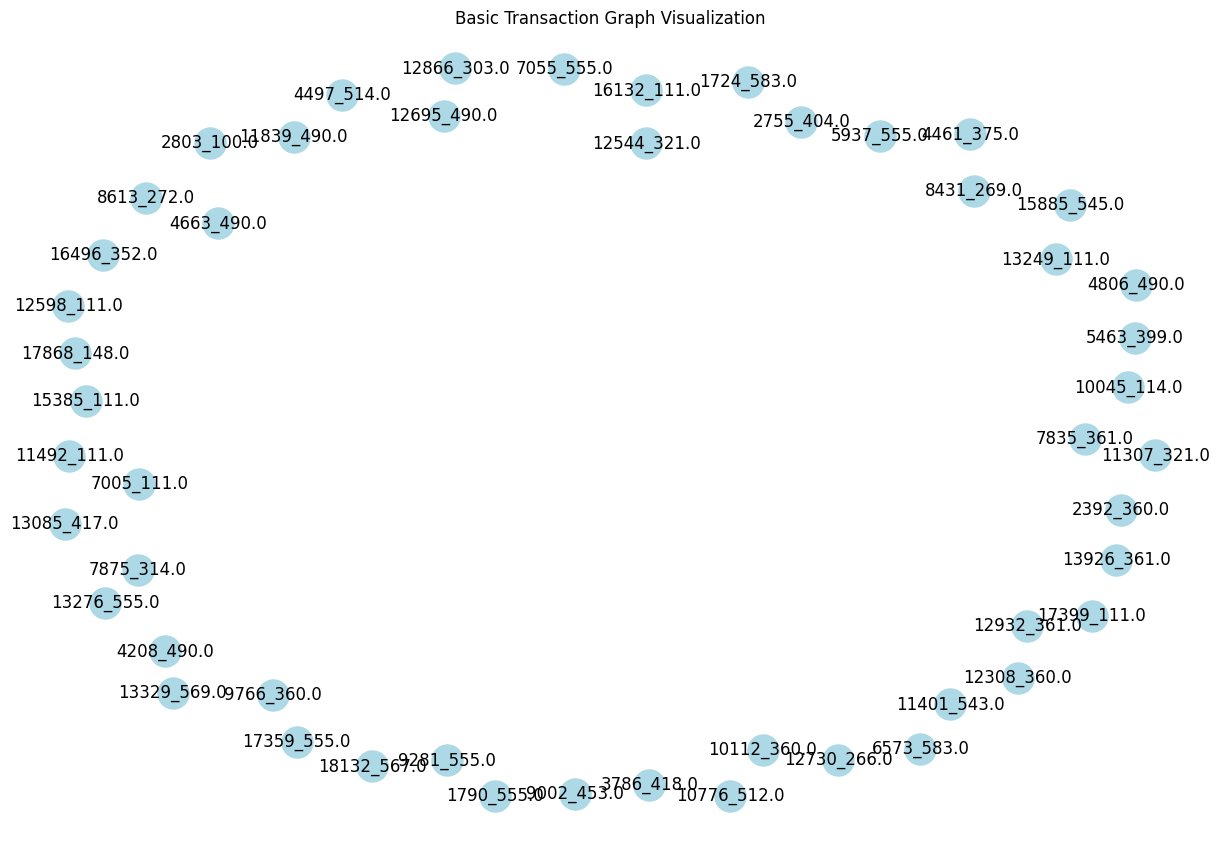

In [102]:
import networkx as nx
import matplotlib.pyplot as plt
import pickle

# Load the saved graph using pickle
with open("fraud_transaction_graph.gpickle", "rb") as f:
    G = pickle.load(f)

# Draw the graph (plot only a subset for better clarity)
plt.figure(figsize=(12, 8))
subset_G = G.subgraph(list(G.nodes)[:50])  # Visualizing only 50 nodes

pos = nx.spring_layout(subset_G, seed=42)  # Layout for better spacing
nx.draw(subset_G, pos, with_labels=True, node_size=500, node_color="lightblue", edge_color="gray")

plt.title("Basic Transaction Graph Visualization")
plt.show()


In [103]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt


In [104]:
with open("fraud_transaction_graph.gpickle", "rb") as f:
    G = pickle.load(f)


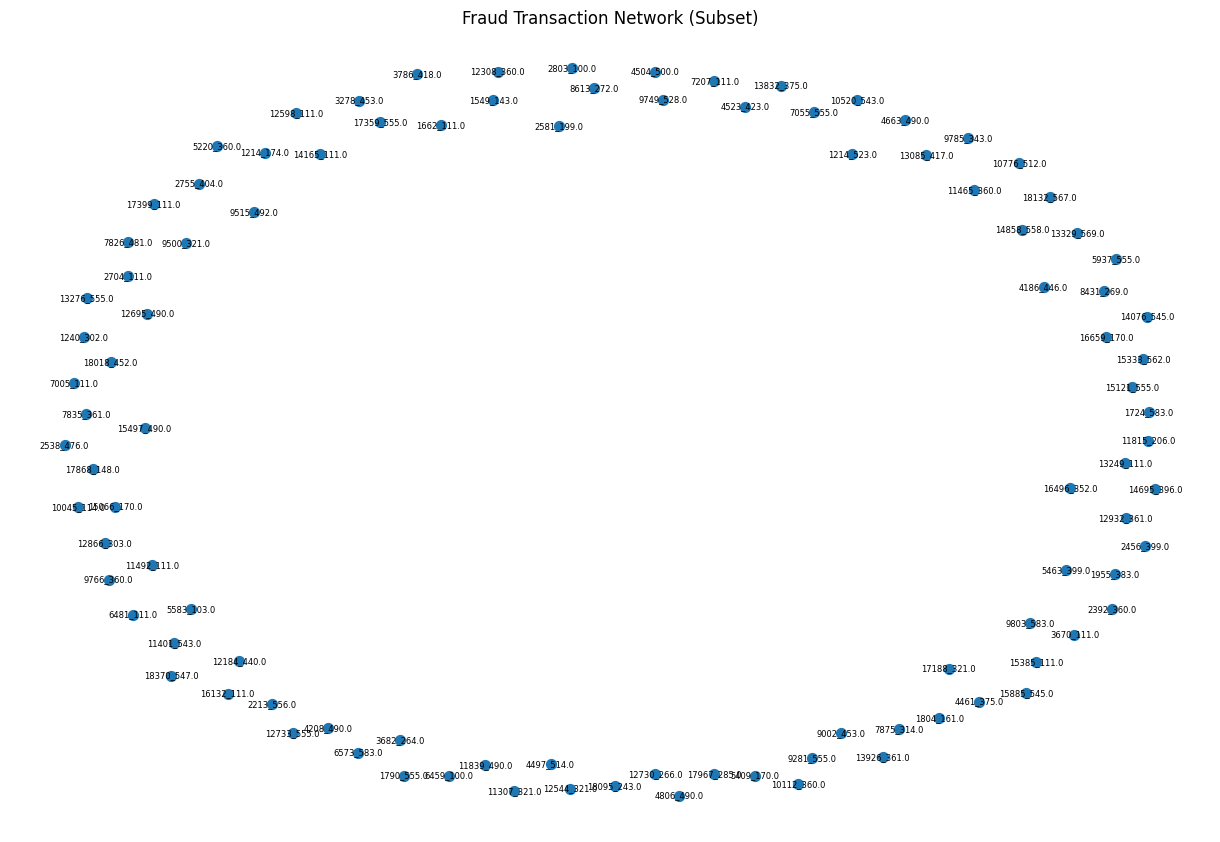

In [105]:
plt.figure(figsize=(12, 8))

# Extract a small subgraph (first 100 nodes for clarity)
subgraph_nodes = list(G.nodes)[:100]  # Adjust the number if needed
subG = G.subgraph(subgraph_nodes)

# Draw the graph
pos = nx.spring_layout(subG, seed=42)  # Positioning for clarity
nx.draw(subG, pos, with_labels=True, node_size=50, font_size=6, edge_color="gray")

plt.title("Fraud Transaction Network (Subset)")
plt.show()


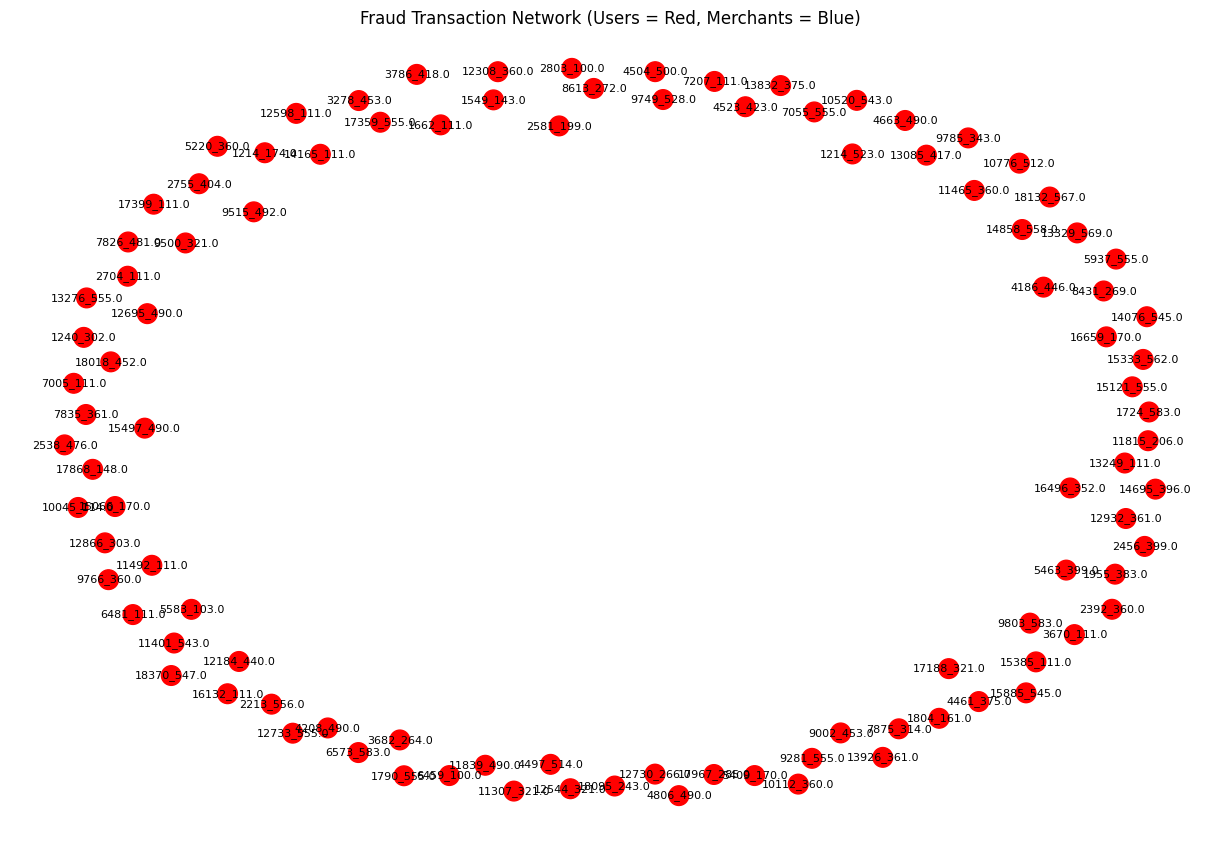

In [106]:
plt.figure(figsize=(12, 8))

# Assign colors to nodes based on type
node_colors = ["red" if G.nodes[node]["type"] == "user" else "blue" for node in subG.nodes]

# Draw the graph with color differentiation
pos = nx.spring_layout(subG, seed=42)
nx.draw(subG, pos, with_labels=True, node_size=200, font_size=8, edge_color="gray", node_color=node_colors)

plt.title("Fraud Transaction Network (Users = Red, Merchants = Blue)")
plt.show()


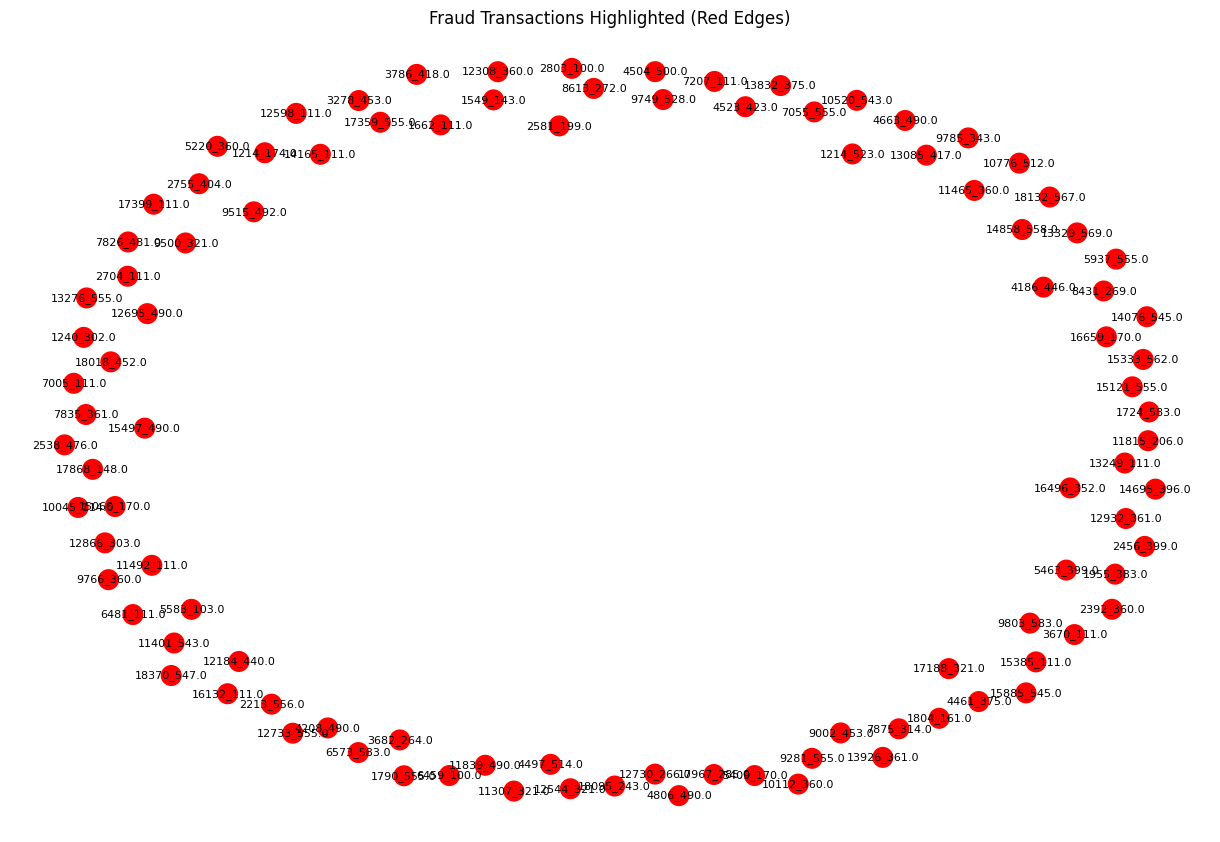

In [107]:
plt.figure(figsize=(12, 8))

# Color fraud transactions red
edge_colors = ["red" if G[u][v]["is_fraud"] == 1 else "gray" for u, v in subG.edges]

# Draw the graph with fraud edges highlighted
nx.draw(subG, pos, with_labels=True, node_size=200, font_size=8, edge_color=edge_colors, node_color=node_colors)

plt.title("Fraud Transactions Highlighted (Red Edges)")
plt.show()


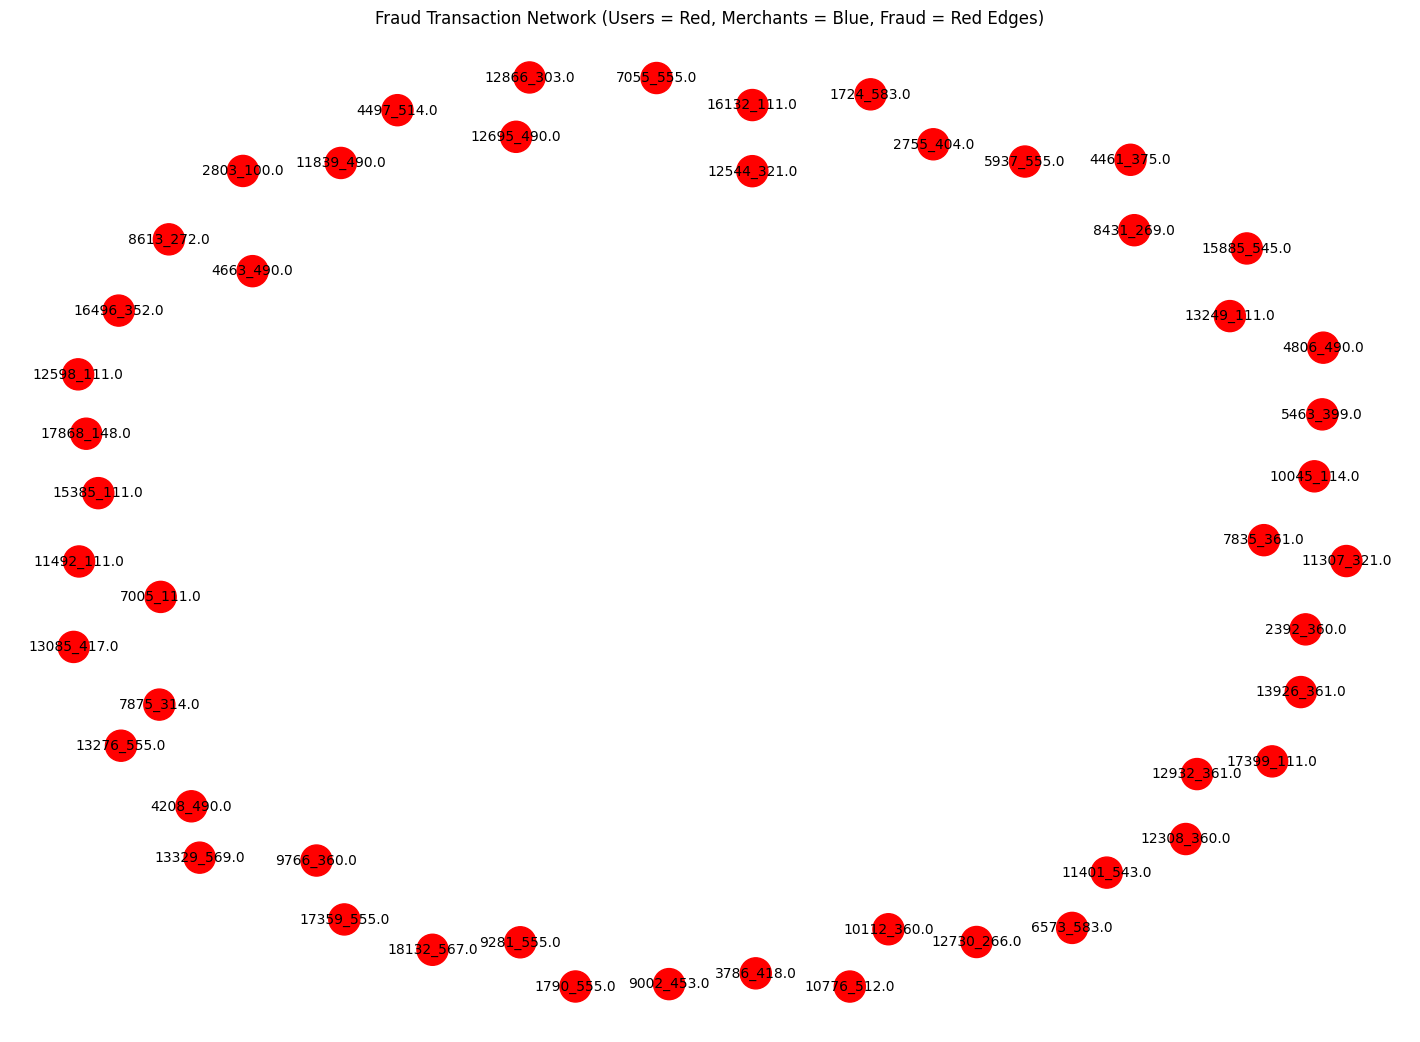

In [108]:
import matplotlib.pyplot as plt
import networkx as nx

# Use a subset of the graph (first 50 nodes) for clarity
subG = G.subgraph(list(G.nodes)[:50])

plt.figure(figsize=(14, 10))

# Use a force-directed layout for better spacing
pos = nx.spring_layout(subG, seed=42)

# Assign colors: Red for users, Blue for merchants
node_colors = ["red" if subG.nodes[node]["type"] == "user" else "blue" for node in subG.nodes]

# Assign edge colors: Red for fraud, Gray for normal
edge_colors = ["red" if subG[u][v]["is_fraud"] == 1 else "gray" for u, v in subG.edges]

# Draw graph
nx.draw(subG, pos, with_labels=True, node_size=500, font_size=10, edge_color=edge_colors, node_color=node_colors)

plt.title("Fraud Transaction Network (Users = Red, Merchants = Blue, Fraud = Red Edges)")
plt.show()


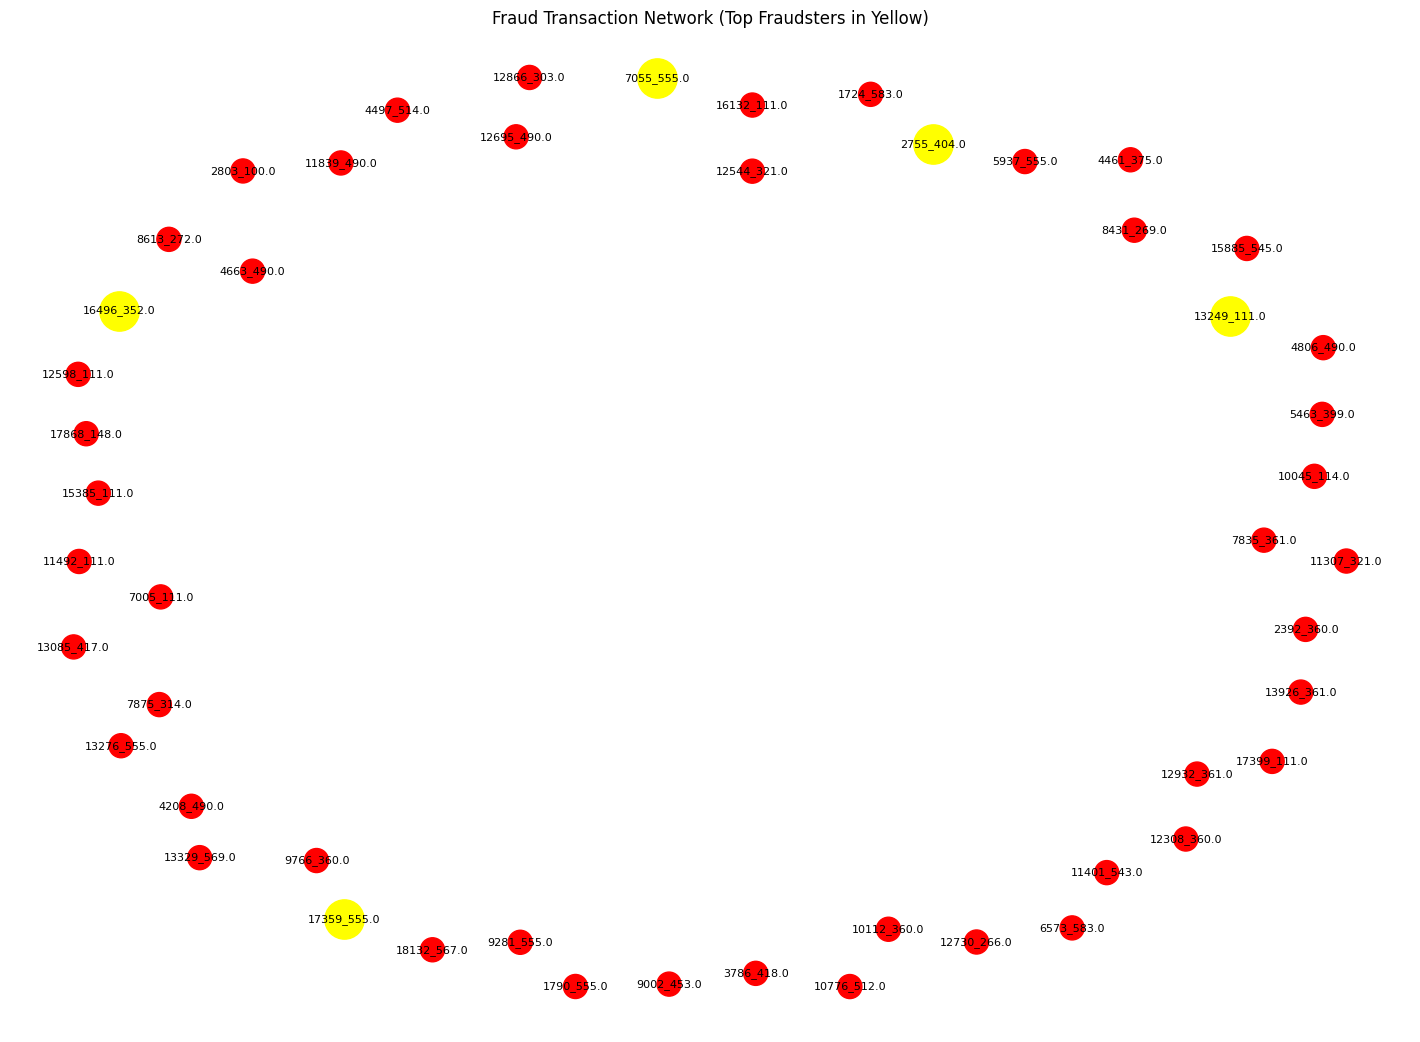

In [109]:
import matplotlib.pyplot as plt
import networkx as nx

# Use a subset of the graph for clarity
subG = G.subgraph(list(G.nodes)[:50])

plt.figure(figsize=(14, 10))

# Generate a layout
pos = nx.spring_layout(subG, seed=42)

# Get node types and colors
node_colors = ["red" if subG.nodes[node]["type"] == "user" else "blue" for node in subG.nodes]

# Get edge colors (fraud = red, normal = gray)
edge_colors = ["red" if subG[u][v]["is_fraud"] == 1 else "gray" for u, v in subG.edges]

# Get node sizes (bigger for high-degree users)
node_sizes = [300 + subG.degree(node) * 50 for node in subG.nodes]

# Draw nodes and edges
nx.draw(subG, pos, node_color=node_colors, edge_color=edge_colors, node_size=node_sizes, with_labels=True, font_size=8)

# Draw edge labels (transaction amounts)
edge_labels = {(u, v): f"${subG[u][v]['amount']}" for u, v in subG.edges}
nx.draw_networkx_edge_labels(subG, pos, edge_labels=edge_labels, font_size=7)

# Highlight top fraudsters (most fraud transactions)
fraud_counts = {node: sum(subG[node][v]["is_fraud"] for v in subG.neighbors(node)) for node in subG.nodes}
top_fraudsters = sorted(fraud_counts, key=fraud_counts.get, reverse=True)[:5]
nx.draw_networkx_nodes(subG, pos, nodelist=top_fraudsters, node_color="yellow", node_size=800)

plt.title("Fraud Transaction Network (Top Fraudsters in Yellow)")
plt.show()


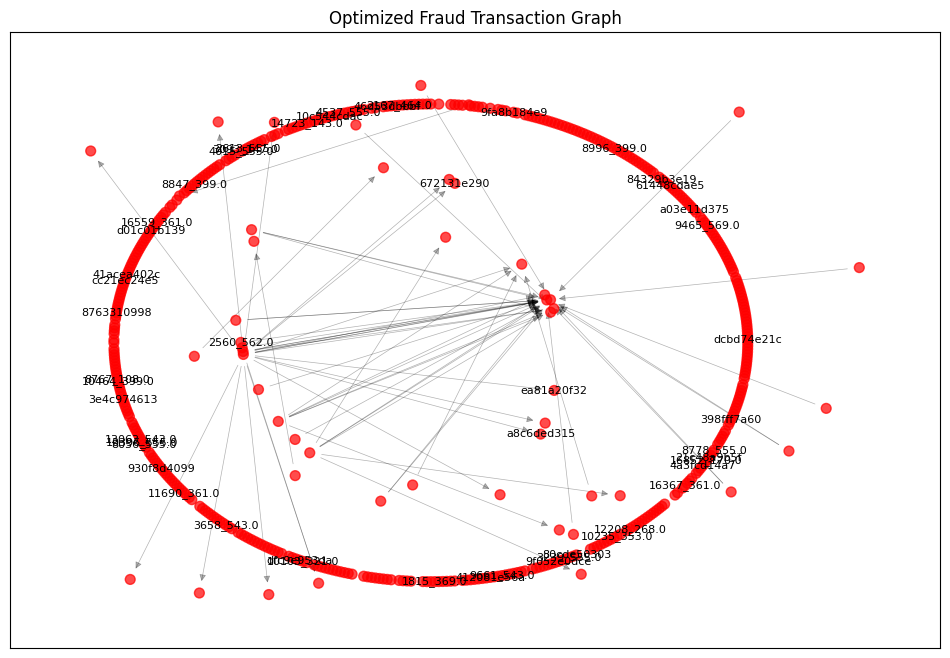

In [110]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import pickle

# Load the graph using pickle
with open("fraud_transaction_graph.gpickle", "rb") as f:
    G = pickle.load(f)

# Sample a subset of nodes (e.g., 500) to reduce rendering time
sample_nodes = random.sample(list(G.nodes()), min(500, len(G)))
G_sub = G.subgraph(sample_nodes)

# Choose a faster layout algorithm
pos = nx.kamada_kawai_layout(G_sub)

# Draw nodes
plt.figure(figsize=(12, 8))
node_colors = ['yellow' if G_sub.nodes[n].get("type") == "fraudulent" else 'red' for n in G_sub.nodes()]
nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=50, alpha=0.7)

# Draw edges with reduced transparency
nx.draw_networkx_edges(G_sub, pos, alpha=0.3, width=0.5)

# Draw labels (only a few to avoid clutter)
sample_labels = {n: n for n in random.sample(sample_nodes, min(50, len(sample_nodes)))}
nx.draw_networkx_labels(G_sub, pos, labels=sample_labels, font_size=8)

plt.title("Optimized Fraud Transaction Graph")
plt.show()


In [111]:
from sklearn.metrics import accuracy_score, precision_score

y_pred_xgb = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")


Accuracy: 0.8954
Precision: 0.4704


In [112]:
def rule_high_amount_night(transaction):
    return (
        transaction["TransactionAmt"] > 10000 and
        0 <= transaction["Hour"] <= 4
    )


In [113]:
def apply_rules(transaction, rules):
    for rule in rules:
        if rule(transaction):
            return True  # If any rule is triggered
    return False


In [114]:
def rule_first_transaction(transaction):
    return transaction.get("isFirstTransaction", False)



In [115]:
blacklisted_entities = ['merchant_42', 'user_1234']  # Example list

def rule_blacklisted_merchant(transaction):
    return (
        transaction.get("merchant_id") in blacklisted_entities or
        transaction.get("user_id") in blacklisted_entities
    )


In [116]:
# Pick a sample transaction (e.g., 5th row)
transaction = df_balanced.iloc[5].to_dict()


In [117]:
rules = [rule_high_amount_night, rule_first_transaction, rule_blacklisted_merchant]
result = apply_rules(transaction, rules)
print("Fraud Detected by Rules:" if result else "No rule-based fraud detected.")


No rule-based fraud detected.


In [118]:
def flag_rule_based_fraud(row):
    transaction = row.to_dict()
    return apply_rules(transaction, rules)

# Create a new column in your dataset
df_balanced["RuleBasedFlag"] = df_balanced.apply(flag_rule_based_fraud, axis=1)

# Count how many transactions were flagged by the rules
print("Total rule-based frauds flagged:", df_balanced["RuleBasedFlag"].sum())


Total rule-based frauds flagged: 0


In [119]:
# Add XGBoost predictions to your dataframe (just make sure indexes match)
df_balanced = df_balanced.reset_index(drop=True)
y_pred_xgb_series = pd.Series(y_pred_xgb, name="ML_Prediction")

# Add prediction column (for test set only if using X_test)
df_balanced.loc[y_test.index, "ML_Prediction"] = y_pred_xgb_series.values


In [120]:
# Replace NaN with 0 (assuming NaN means no fraud)
df_balanced["ML_Prediction"] = df_balanced["ML_Prediction"].fillna(0)

# Convert to integer (0 or 1)
df_balanced["ML_Prediction"] = df_balanced["ML_Prediction"].astype(int)

# Now safely apply bitwise OR
df_balanced["FinalPrediction"] = df_balanced["ML_Prediction"] | df_balanced["RuleBasedFlag"].astype(int)


In [121]:
print(df_balanced["ML_Prediction"].unique())
print(df_balanced["RuleBasedFlag"].unique())
print(df_balanced.dtypes[["ML_Prediction", "RuleBasedFlag"]])


[0 1]
[False]
ML_Prediction    int32
RuleBasedFlag     bool
dtype: object


In [122]:
df_balanced["FinalPrediction"] = df_balanced["ML_Prediction"] | df_balanced["RuleBasedFlag"]


In [123]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = df_balanced["isFraud"]
y_pred = df_balanced["FinalPrediction"]

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))



[[282608   6152]
 [ 24412   5464]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95    288760
           1       0.47      0.18      0.26     29876

    accuracy                           0.90    318636
   macro avg       0.70      0.58      0.61    318636
weighted avg       0.88      0.90      0.88    318636



In [124]:
print(df_balanced.columns)

Index(['TransactionAmt_Log', 'Day', 'TransactionAmt', 'TransactionDT', 'Hour',
       'isFraud', 'amt_ratio', 'txn_time_diff', 'RuleBasedFlag',
       'ML_Prediction', 'FinalPrediction'],
      dtype='object')


In [125]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',  # this gives more importance to minority class
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', random_state=42)

In [126]:
from xgboost import XGBClassifier

# scale_pos_weight = ratio of class 0 to class 1
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    scale_pos_weight=scale,   # give more focus to fraud class
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [127]:
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]


In [128]:
rf_preds = (rf_probs >= 0.3).astype(int)
xgb_preds = (xgb_probs >= 0.3).astype(int)


In [129]:
from sklearn.metrics import classification_report, confusion_matrix

print("Random Forest (Threshold 0.3)")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


Random Forest (Threshold 0.3)
[[54331  3422]
 [ 1225  4750]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     57753
           1       0.58      0.79      0.67      5975

    accuracy                           0.93     63728
   macro avg       0.78      0.87      0.82     63728
weighted avg       0.94      0.93      0.93     63728



In [130]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, preds))



Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      0.74      0.85     57753
           1       0.28      0.97      0.43      5975

    accuracy                           0.76     63728
   macro avg       0.64      0.85      0.64     63728
weighted avg       0.93      0.76      0.81     63728


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     57753
           1       0.36      0.95      0.52      5975

    accuracy                           0.83     63728
   macro avg       0.68      0.89      0.71     63728
weighted avg       0.93      0.83      0.86     63728


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.85      0.92     57753
           1       0.40      0.94      0.56      5975

    accuracy                           0.86     63728
   macro avg       0.70      0.90      0.74     63728
weighted avg       0.94   

In [131]:
# Apply the 0.3 threshold for Random Forest and XGBoost predictions
rf_preds = (rf_probs >= 0.3).astype(int)
xgb_preds = (xgb_probs >= 0.3).astype(int)



In [136]:
# Convert both columns to boolean
df_balanced["ML_Prediction"] = df_balanced["ML_Prediction"].astype(bool)
df_balanced["RuleBasedFlag"] = df_balanced["RuleBasedFlag"].astype(bool)

# Now combine rule-based and ML predictions for final prediction
df_balanced["FinalPrediction"] = df_balanced["ML_Prediction"] | df_balanced["RuleBasedFlag"]

# Evaluate performance
from sklearn.metrics import confusion_matrix, classification_report

y_true = df_balanced["isFraud"]
y_pred = df_balanced["FinalPrediction"]

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))




[[282608   6152]
 [ 24412   5464]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95    288760
           1       0.47      0.18      0.26     29876

    accuracy                           0.90    318636
   macro avg       0.70      0.58      0.61    318636
weighted avg       0.88      0.90      0.88    318636



In [138]:
# Assuming these were your models' raw prediction probabilities:
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Apply a threshold (e.g., 0.3) to get binary predictions
rf_preds_binary = (rf_probs > 0.3).astype(int)
xgb_preds_binary = (xgb_probs > 0.3).astype(int)



In [139]:
# Map predictions back to df_balanced by index
df_balanced.loc[y_test.index, "ML_Prediction_RF"] = rf_preds_binary
df_balanced.loc[y_test.index, "ML_Prediction_XGB"] = xgb_preds_binary.astype(bool)

# Ensure rule-based flags are binary
df_balanced["RuleBasedFlag"] = df_balanced["RuleBasedFlag"].astype(int)

# Combine predictions: fraud if either model or rule-based flags it
df_balanced["FinalPrediction"] = df_balanced["ML_Prediction_XGB"] | df_balanced["RuleBasedFlag"]

# Evaluate hybrid model
y_true = df_balanced.loc[y_test.index, "isFraud"]
y_pred = df_balanced.loc[y_test.index, "FinalPrediction"]

from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.85      0.92     57753
           1       0.40      0.94      0.56      5975

    accuracy                           0.86     63728
   macro avg       0.70      0.90      0.74     63728
weighted avg       0.94      0.86      0.88     63728


Confusion Matrix:
 [[49331  8422]
 [  360  5615]]


In [140]:
# Convert predictions to boolean (0 or 1)
df_balanced["ML_Prediction_RF"] = df_balanced["ML_Prediction_RF"].astype(bool)
df_balanced["ML_Prediction_XGB"] = df_balanced["ML_Prediction_XGB"].astype(bool)
df_balanced["RuleBasedFlag"] = df_balanced["RuleBasedFlag"].astype(bool)

# Combine the predictions (Logical OR)
df_balanced["FinalPrediction"] = (df_balanced["ML_Prediction_RF"] | df_balanced["ML_Prediction_XGB"] | df_balanced["RuleBasedFlag"]).astype(int)


In [141]:
y_true = df_balanced["isFraud"]
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, df_balanced["FinalPrediction"]))
print(confusion_matrix(y_true, df_balanced["FinalPrediction"]))


              precision    recall  f1-score   support

           0       0.99      0.17      0.29    288760
           1       0.11      0.99      0.20     29876

    accuracy                           0.25    318636
   macro avg       0.55      0.58      0.24    318636
weighted avg       0.91      0.25      0.28    318636

[[ 49231 239529]
 [   298  29578]]


In [143]:
import joblib
import xgboost as xgb

# Save Random Forest model
joblib.dump(rf_model, "rf_model.pkl")

# Save XGBoost model
xgb_model.save_model("xgb_model.json")



In [3]:
import joblib

# Load the model
rf_model = joblib.load(r"C:\\Users\\amish\\fraud ml\\fraud-api\\rf_model.pkl")

# Check number of features
print(rf_model.n_features_in_)


6


In [4]:
print(rf_model.feature_names_in_)


['TransactionAmt' 'TransactionAmt_Log' 'Hour' 'Day' 'amt_ratio'
 'txn_time_diff']
